# 1. Data

In [1]:
import numpy as np
import importlib
from data.data_reader import Data
%load_ext autoreload
%autoreload 2

# from preprocessing import pre
Data_params_file = 'Configs/Data_params.py'
loader = importlib.machinery.SourceFileLoader('Data_params', Data_params_file)
Data_params = loader.load_module()

In [2]:
data = Data(**Data_params.data_base)

In [3]:
x_train, x_test, y_train, y_test = data.get_train_test()

# 2. Network

In [4]:
from network.network_builder import get_tissue_specific_maps
import pandas as pd

In [5]:
# select tissues name from gtex and append it in Network_params.tissues list 
Network_params_file = 'Configs/Network_params.py'
loader = importlib.machinery.SourceFileLoader('Network_params', Network_params_file)
Network_params = loader.load_module()

In [6]:
# TIME-CONSUMING  ALERT!!!!!!!!!!!!! 
# insted of runing this cell multiple times,
# save the tissue_maps and load for next time trainig
# tissue_maps = get_tissue_specific_maps(genes=data.columns.levels[0],
#                                        Network_params=Network_params)

In [7]:
# for the first time save it 
# import pickle
# with open('tissue_maps.pkl', 'wb') as f:
#     pickle.dump(tissue_maps, f)

In [8]:
# for the second time load it 
import pickle
with open('tissues_maps.pkl', 'rb') as f:
    tissues_maps = pickle.load(f)

In [9]:
for t in tissues_maps.keys():
    print(t)
    for i in range(len(tissues_maps[t])):
        print(f"{i+1}, shape:{tissues_maps[t][i].shape}, connection: {sum(tissues_maps[t][i].sum(axis=1)>0)}")   
    print("#"*50, "\n")

Thyroid
1, shape:(8435, 1616), connection: 4501
2, shape:(1616, 1120), connection: 1616
3, shape:(1120, 505), connection: 1120
4, shape:(505, 169), connection: 505
5, shape:(169, 29), connection: 169
6, shape:(29, 1), connection: 29
################################################## 

Testis
1, shape:(9004, 1616), connection: 4770
2, shape:(1616, 1120), connection: 1616
3, shape:(1120, 505), connection: 1120
4, shape:(505, 169), connection: 505
5, shape:(169, 29), connection: 169
6, shape:(29, 1), connection: 29
################################################## 

Pancreas
1, shape:(8390, 1616), connection: 4500
2, shape:(1616, 1120), connection: 1616
3, shape:(1120, 505), connection: 1120
4, shape:(505, 169), connection: 505
5, shape:(169, 29), connection: 169
6, shape:(29, 1), connection: 29
################################################## 

Stomach
1, shape:(8436, 1616), connection: 4518
2, shape:(1616, 1120), connection: 1616
3, shape:(1120, 505), connection: 1120
4, shape:(505, 

# 3. Model

* `ST: Singel Tissue`
* `MT: Multiple Tissue`
* `I: Input layer`
* `G: GeneSelection layer`
* `D: Diagonal layer`
* `HS: Hidden Sparse`
* `HD: Hidden Dense`
* `O: Output`

In [10]:
from model.model_utils import get_th, plot_history
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, LearningRateScheduler, TensorBoard
from keras.utils import plot_model

In [ ]:
tissue_name = 'Prostate'
prostate_maps = tissues_maps[tissue_name]

## 3.1 Input --> GeneSelection --> Output
* `ST_I_G_O`

In [ ]:
from model.Models_builder import I_G_O

In [ ]:
I_G_O_model = I_G_O(data, prostate_maps, 'Prostate', w_reg = 0.01, learning_rate=0.01)

In [ ]:
# Callbacks
def scheduler(epoch, lr):
    if epoch < 10:
        return lr
    else:
        return lr * 0.9
    
LearningRateScheduler_callback = LearningRateScheduler(scheduler)
TensorBoard_callback = TensorBoard(log_dir="./TensorBoard")
EarlyStopping_callback = EarlyStopping(monitor='val_loss',
                                       patience=20, verbose=1,
                                       restore_best_weights=True) 
ReduceLROnPlateau_callback = ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=20, min_lr=0.000001)

callbacks = [EarlyStopping_callback,
             LearningRateScheduler_callback,
             ReduceLROnPlateau_callback]

In [ ]:
history = I_G_O_model.fit(x_train, 
                          y_train,
                          validation_data=(x_test, y_test),
                          epochs=200,
                          batch_size=250,
                          callbacks=callbacks,
                          verbose=2)

In [ ]:
plot_history(history)

In [ ]:
y_prob = I_G_O_model.predict(x_train)
get_th(y_train, y_prob)

In [ ]:
y_prob = I_G_O_model.predict(x_test)
get_th(y_test, y_prob)

## 3.2 Input --> GeneSelection --> Diagonal --> Output
* `ST_I_G_D_O`

In [ ]:
from model.Models_builder import I_G_D_O

In [ ]:
I_G_D_O_model = I_G_D_O(data, prostate_maps, 'Prostate',
                        w_regs=[0.001, 0.001], learning_rate=0.01)

In [ ]:
# Callbacks
def scheduler(epoch, lr):
    if epoch < 25:
        return lr
    else:
        return lr * 0.9
    
LearningRateScheduler_callback = LearningRateScheduler(scheduler)
TensorBoard_callback = TensorBoard(log_dir="./TensorBoard")
EarlyStopping_callback = EarlyStopping(monitor='val_loss',
                                       patience=20, verbose=1,
                                       restore_best_weights=True) 
ReduceLROnPlateau_callback = ReduceLROnPlateau(monitor='val_loss', factor=0.99,
                              patience=10, min_lr=0.000001)

callbacks = [EarlyStopping_callback,
             LearningRateScheduler_callback]
#              ReduceLROnPlateau_callback]

In [ ]:
history = I_G_D_O_model.fit(x_train, 
                            y_train,
                            validation_data=(x_test,y_test), 
                            epochs=20,
                            batch_size=250,
                            callbacks=callbacks,
                            verbose=2)

In [ ]:
plot_history(history)

In [ ]:
y_prob = I_G_D_O_model.predict(x_train)
get_th(y_train, y_prob)

In [ ]:
y_prob = I_G_D_O_model.predict(x_test)
get_th(y_test, y_prob)

## 3.3 Input --> GeneSelection --> Hidden Dense(3) --> Output
* `ST_I_G_HD3_O`

In [ ]:
from model.Models_builder import I_G_HD3_O

In [ ]:
I_G_HD3_O_model = I_G_HD3_O(data, prostate_maps, 'Prostate',
                            hidden_layers=(100,50,10),
                            w_regs =[0.1,0.01,0.01,0.001],
                            learning_rate=0.001)

In [ ]:
# Callbacks
def scheduler(epoch, lr):
    if epoch < 50:
        return lr
    else:
        return lr * 0.9
    
LearningRateScheduler_callback = LearningRateScheduler(scheduler)
TensorBoard_callback = TensorBoard(log_dir="./TensorBoard")
EarlyStopping_callback = EarlyStopping(monitor='val_loss',
                                       patience=20, verbose=1,
                                       restore_best_weights=True) 
ReduceLROnPlateau_callback = ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=20, min_lr=0.000001)

callbacks = [EarlyStopping_callback,
             LearningRateScheduler_callback,
             ReduceLROnPlateau_callback]

In [ ]:
history = I_G_HD3_O_model.fit(x_train, 
                              y_train,
                              validation_data=(x_test,y_test), 
                              epochs=100,
                              batch_size=250,
                              callbacks=callbacks,
                              verbose=2)

In [ ]:
plot_history(history)

In [ ]:
y_prob = I_G_HD3_O_model.predict(x_train)
get_th(y_train, y_prob)

In [ ]:
y_prob = I_G_HD3_O_model.predict(x_test)
get_th(y_test, y_prob)

## 3.4 Input --> GeneSelection --> Diagonal --> Hidden Sparse(5) --> Output
* `ST_I_G_D_HS5_O`

In [ ]:
from model.Models_builder import I_G_D_HS5_O

In [ ]:
I_G_D_HS5_O_model = I_G_D_HS5_O(data, prostate_maps, 'Prostate',
                                      w_regs=[0.0]*7,
                                      drop_rate=[.1, .1, .1, .1, .1, .1],
                                      learning_rate=.1)

In [ ]:
# Callbacks
def scheduler(epoch, lr):
    if epoch < 50:
        return lr
    else:
        return lr * 0.9
    
LearningRateScheduler_callback = LearningRateScheduler(scheduler)
TensorBoard_callback = TensorBoard(log_dir="./TensorBoard")
EarlyStopping_callback = EarlyStopping(monitor='val_loss',
                                       patience=20, verbose=1,
                                       restore_best_weights=True) 
ReduceLROnPlateau_callback = ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=20, min_lr=0.000001)
callbacks = [TensorBoard_callback]

In [ ]:
history = I_G_D_HS5_O_model.fit(x_train, 
                                y_train,
                                validation_data=(x_test,y_test), 
                                epochs=200,
                                batch_size=250,
                                callbacks=callbacks,
                                verbose=2)

In [ ]:
plot_history(history)

In [ ]:
y_prob = I_G_D_HS5_O_model.predict(x_train)
get_th(y_train, y_prob)

In [ ]:
y_prob = I_G_D_HS5_O_model.predict(x_test)
get_th(y_test, y_prob)

## 3.5 Input --> GeneSelection --> Diagonal --> Sparse(5) --> Output(7)
* `ST_I_G_D_HS5_O7`

In [ ]:
from model.Models_builder import I_G_D_HS5_O7

In [ ]:
I_G_D_HS5_O7_model = I_G_D_HS5_O7(data, prostate_maps,
                                  'Prostate',
                                  w_regs=[.0,.0,.0,.0,.0,.0,.0], # 7 
                                  w_regs_outcome=[.1,.0,.0,.0,.0,.0,.0], # 7
                                  drop_rate=[.4,.1,.1,.1,.1], # 5
                                  loss_weights=[1,2,4,8,16,32,64],
                                  learning_rate=.01)

In [ ]:
# plot_model(I_G_D_HS5_O7_model,
#            to_file = f'I_G_D_HS5_O7_model_model.jpg',
#            expand_nested=True,
#            show_layer_activations=True,
#            show_shapes = True,
#            show_layer_names = True)

In [ ]:
# Callbacks
def scheduler(epoch, lr):
    if epoch < 20:
        return lr
    else:
        return 0.001
LearningRateScheduler_callback = LearningRateScheduler(scheduler)
TensorBoard_callback = TensorBoard(log_dir="./TensorBoard")
EarlyStopping_callback = EarlyStopping(monitor='val_loss',
                                       patience=20, verbose=1,
                                       restore_best_weights=True) 
ReduceLROnPlateau_callback = ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=20, min_lr=0.000001)
callbacks = [LearningRateScheduler_callback,
             EarlyStopping_callback,
             ReduceLROnPlateau_callback]

In [ ]:
history = I_G_D_HS5_O7_model.fit(x_train, 
                                 y_train,
                                 validation_data=(x_test,y_test), 
                                 epochs=200,
                                 batch_size=250,
                                 callbacks=callbacks,
                                 verbose=2)

In [ ]:
y_prob = I_G_D_HS5_O7_model.predict(x_train)
for i in range(len(y_prob)):
    get_th(y_train, y_prob[i])

In [ ]:
y_prob = I_G_D_HS5_O7_model.predict(x_test)
for i in range(len(y_prob)):
    get_th(y_test, y_prob[i])

In [ ]:
plot_history(history)

## 3.6 Input --> GeneSelection --> Diagonal --> Sparse(5) --> Outcome(7) --> Output
* `ST_I_G_D_HS5_O7_O`

In [ ]:
from model.Models_builder import ST_I_G_D_HS5_O7_O

In [ ]:
ST_I_G_D_HS5_O7_O_model = ST_I_G_D_HS5_O7_O(data, prostate_maps,
                                            'Prostate',
                                            w_regs=[.0,.0,.0,.0,.0,.0,.0], # 7 
                                            w_regs_outcome=[.1,.0,.0,.0,.0,.0,.0], # 7
                                            drop_rate=[.4,.1,.1,.1,.1], # 5
                                            learning_rate=.01)

In [ ]:
# plot_model(I_G_D_HS5_O7_O_model,
#            to_file = f'I_G_D_HS5_O7_O_model.jpg',
#            expand_nested = True,
#            show_layer_activations = True,
#            show_shapes = True,
#            show_layer_names = True)

In [ ]:
# Callbacks
def scheduler(epoch, lr):
    if epoch < 20:
        return lr
    else:
        return 0.001
LearningRateScheduler_callback = LearningRateScheduler(scheduler)
TensorBoard_callback = TensorBoard(log_dir="./TensorBoard")
EarlyStopping_callback = EarlyStopping(monitor='val_loss',
                                       patience=20, verbose=1,
                                       restore_best_weights=True) 
ReduceLROnPlateau_callback = ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=20, min_lr=0.000001)
callbacks = [LearningRateScheduler_callback,
             EarlyStopping_callback,
             ReduceLROnPlateau_callback]

In [ ]:
history = ST_I_G_D_HS5_O7_O_model.fit(x_train, 
                                   y_train,
                                   validation_data=(x_test,y_test),
                                   epochs=200,
                                   batch_size=250,
                                   callbacks=callbacks,
                                   verbose=2)

In [ ]:
plot_history(history)

In [ ]:
y_prob = ST_I_G_D_HS5_O7_O_model.predict(x_train)
get_th(y_train, y_prob)

In [ ]:
y_prob = ST_I_G_D_HS5_O7_O_model.predict(x_test)
get_th(y_test, y_prob)

## 3.7 Input --> GeneSelection --> Diagonal --> Sparse(5) --> Outcome(7) --> Output
* `MT_I_G_D_HS5_O7_O`

In [42]:
from model.Models_builder import MT_I_G_D_HS5_O7_O

In [43]:
MT_I_G_D_HS5_O7_O_model = MT_I_G_D_HS5_O7_O(data, tissues_maps,
                                            w_regs=[.0,.0,.0,.0,.0,.0,.0], # 7 
                                            w_regs_outcome=[.1,.0,.0,.0,.0,.0,.0], # 7
                                            drop_rate=[.4,.1,.1,.1,.1], # 5
                                            learning_rate=.01)

['Thyroid', 'Testis', 'Pancreas', 'Stomach', 'Prostate']
Input --> GeneSelection --> Diagonal --> Sparse(5) --> Output(7) --> Output
w_regs: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
w_regs_outcome: [0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
drop_rate: [0.4, 0.1, 0.1, 0.1, 0.1]
learning_rate: 0.01
Thyroid
9229
(None, 27687)
Testis
9229
(None, 27687)
Pancreas
9229
(None, 27687)
Stomach
9229
(None, 27687)
Prostate
9229
(None, 27687)
Model: "model_52"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input (InputLayer)          [(None, 27687)]              0         []                            
                                                                                                  
 GeneSelection-Thyroid (Gen  (None, 27687)                0         ['input[0][0]']               
 eSelection)                                                     

 Hidden_2-Testis (SparseTF)  (None, 1120)                 2747      ['Dropout_2-Testis[0][0]']    
                                                                                                  
 Hidden_2-Pancreas (SparseT  (None, 1120)                 2747      ['Dropout_2-Pancreas[0][0]']  
 F)                                                                                               
                                                                                                  
 Hidden_2-Stomach (SparseTF  (None, 1120)                 2747      ['Dropout_2-Stomach[0][0]']   
 )                                                                                                
                                                                                                  
 Hidden_2-Prostate (SparseT  (None, 1120)                 2747      ['Dropout_2-Prostate[0][0]']  
 F)                                                                                               
          

                                                                                                  
 Hidden_5-Testis (SparseTF)  (None, 29)                   199       ['Dropout_5-Testis[0][0]']    
                                                                                                  
 Hidden_5-Pancreas (SparseT  (None, 29)                   199       ['Dropout_5-Pancreas[0][0]']  
 F)                                                                                               
                                                                                                  
 Hidden_5-Stomach (SparseTF  (None, 29)                   199       ['Dropout_5-Stomach[0][0]']   
 )                                                                                                
                                                                                                  
 Hidden_5-Prostate (SparseT  (None, 29)                   199       ['Dropout_5-Prostate[0][0]']  
 F)       

                                                                                                  
 Outcome_7-Prostate (Dense)  (None, 1)                    30        ['Hidden_5-Prostate[0][0]']   
                                                                                                  
 Concatenate_outcomes-Thyro  (None, 7)                    0         ['Outcome_1-Thyroid[0][0]',   
 id (Concatenate)                                                    'Outcome_2-Thyroid[0][0]',   
                                                                     'Outcome_3-Thyroid[0][0]',   
                                                                     'Outcome_4-Thyroid[0][0]',   
                                                                     'Outcome_5-Thyroid[0][0]',   
                                                                     'Outcome_6-Thyroid[0][0]',   
                                                                     'Outcome_7-Thyroid[0][0]']   
          

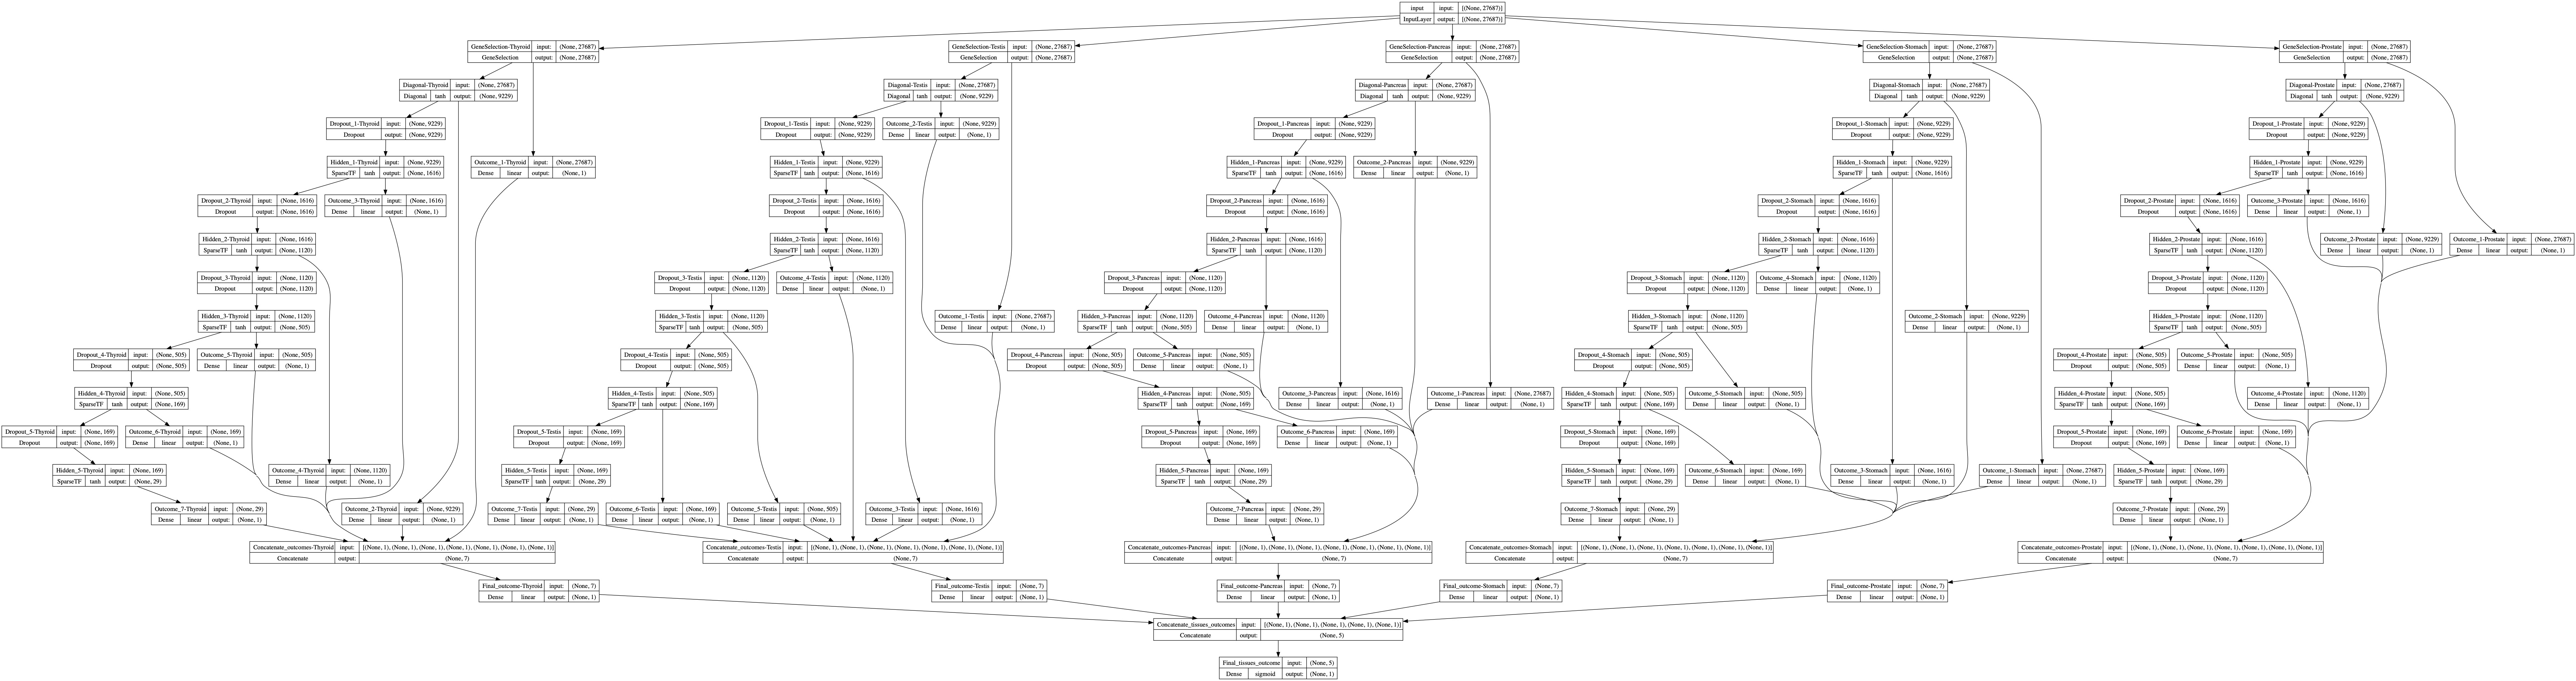

In [44]:
plot_model(MT_I_G_D_HS5_O7_O_model,
           to_file = f'MT_I_G_D_HS5_O7_O_model.jpg',
           expand_nested = True,
           show_layer_activations = True,
           show_shapes = True,
           show_layer_names = True)

In [45]:
# Callbacks
def scheduler(epoch, lr):
    if epoch < 20:
        return lr
    else:
        return 0.001
LearningRateScheduler_callback = LearningRateScheduler(scheduler)
TensorBoard_callback = TensorBoard(log_dir="./TensorBoard")
EarlyStopping_callback = EarlyStopping(monitor='val_loss',
                                       patience=20, verbose=1,
                                       restore_best_weights=True) 
ReduceLROnPlateau_callback = ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=20, min_lr=0.000001)
callbacks = [LearningRateScheduler_callback,
             EarlyStopping_callback,
             ReduceLROnPlateau_callback]

In [46]:
history = MT_I_G_D_HS5_O7_O_model.fit(x_train, 
                                       y_train,
                                       validation_data=(x_test,y_test),
                                       epochs=200,
                                       batch_size=250,
                                       callbacks=callbacks,
                                       verbose=2)

Epoch 1/200


2023-10-08 17:40:33.317836: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2023-10-08 17:40:38.802867: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


4/4 - 8s - loss: 1.6603 - f1: 0.3690 - val_loss: 1.6368 - val_f1: 0.5918 - lr: 0.0100 - 8s/epoch - 2s/step
Epoch 2/200
4/4 - 1s - loss: 1.1561 - f1: 0.4953 - val_loss: 1.1294 - val_f1: 0.0857 - lr: 0.0100 - 1s/epoch - 268ms/step
Epoch 3/200
4/4 - 1s - loss: 0.9863 - f1: 0.4898 - val_loss: 0.9761 - val_f1: 0.6803 - lr: 0.0100 - 963ms/epoch - 241ms/step
Epoch 4/200
4/4 - 1s - loss: 0.8415 - f1: 0.5374 - val_loss: 0.9119 - val_f1: 0.2338 - lr: 0.0100 - 894ms/epoch - 223ms/step
Epoch 5/200
4/4 - 1s - loss: 0.7527 - f1: 0.4517 - val_loss: 0.7859 - val_f1: 0.5893 - lr: 0.0100 - 772ms/epoch - 193ms/step
Epoch 6/200
4/4 - 1s - loss: 0.7033 - f1: 0.6533 - val_loss: 0.7191 - val_f1: 0.2683 - lr: 0.0100 - 944ms/epoch - 236ms/step
Epoch 7/200
4/4 - 1s - loss: 0.6724 - f1: 0.4649 - val_loss: 0.6875 - val_f1: 0.5051 - lr: 0.0100 - 612ms/epoch - 153ms/step
Epoch 8/200
4/4 - 1s - loss: 0.6219 - f1: 0.7195 - val_loss: 0.6939 - val_f1: 0.4348 - lr: 0.0100 - 744ms/epoch - 186ms/step
Epoch 9/200
4/4 - 1s 

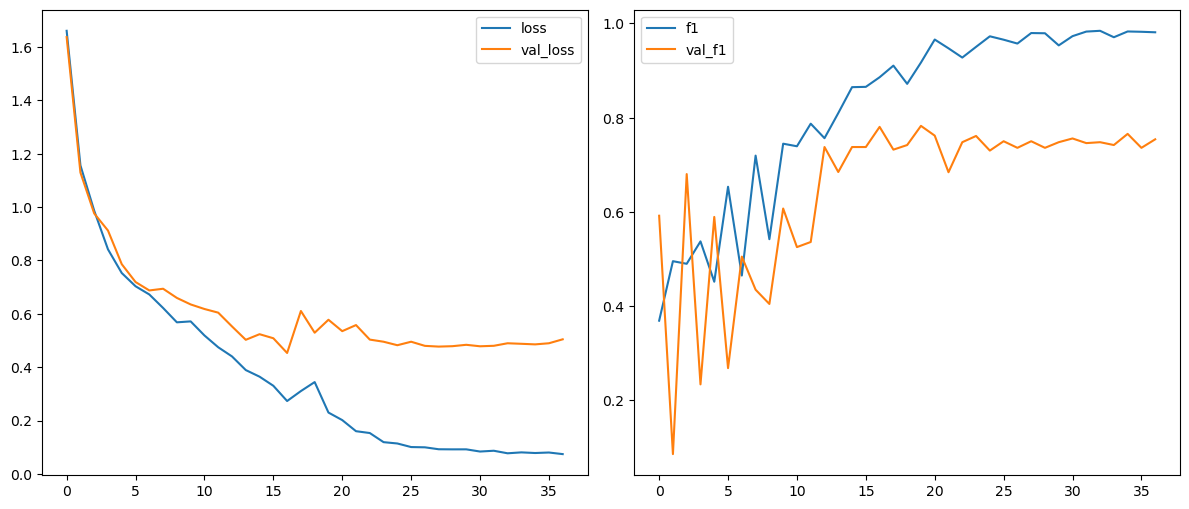

In [47]:
plot_history(history)

In [48]:
y_prob = MT_I_G_D_HS5_O7_O_model.predict(x_train)
get_th(y_train, y_prob)

2023-10-08 17:41:01.253022: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


26/26 [==============================] - 1s 33ms/step
Best threshold to maximize the F1-score: 0.4199999999999998

Metrics for best threshold:
    accuracy  precision        f1    recall    th
32  0.969059   0.972549  0.952015  0.932331  0.42


In [49]:
y_prob = MT_I_G_D_HS5_O7_O_model.predict(x_test)
get_th(y_test, y_prob)

7/7 [==============================] - 0s 48ms/step
Best threshold to maximize the F1-score: 0.5699999999999997

Metrics for best threshold:
    accuracy  precision        f1    recall    th
47  0.876847   0.888889  0.793388  0.716418  0.57


# 4. Interpretability

In [19]:
import shap
from keras import Model
import numpy 

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [119]:
GeneSelection_features = [f'{g}_{s}' for g, s in data.columns]
Diagonal_features = data.columns.levels[0].tolist()
features = {'GeneSelection': GeneSelection_features, 'Diagonal':Diagonal_features}

pathways = pd.read_csv('../_database/pathways/Reactome2023/ReactomePathways.txt',
                       sep='\t', header=None)
pathways.columns = ['reactome_id', 'pathway_name', 'species']
pathways = pathways[pathways.species == 'Homo sapiens'].reset_index(drop=True)
pathways.drop('species', inplace=True,axis=1)
pathways = dict(zip(pathways.reactome_id, pathways.pathway_name))

## 4.1 Input --> GeneSelection --> Output
* `ST_I_G_O_model`

In [ ]:
# look is there any difference between shpa value of input layer and gene selection 
# since in gene selection there are some zero values there should be same shap value 
# for these layers

In [ ]:
explainer = shap.DeepExplainer(ST_I_G_O_model, x_train)
shap_values = explainer.shap_values(x_train)

In [ ]:
shap.summary_plot(shap_values, x_test, feature_names=input_features)

## 4.2  Input --> GeneSelection --> Diagonal --> Output
* `ST_I_G_D_O_model`

In [ ]:
[l.name for l in ST_I_G_D_O_model.layers]

### 4.2.1 Input Features

In [ ]:
explainer = shap.DeepExplainer(ST_I_G_D_O_model, x_train)
shap_values = explainer.shap_values(x_train)

In [ ]:
shap.summary_plot(shap_values, x_test, feature_names=input_features)

### 4.2.2 Diagonal Features

In [ ]:
daigonal_features = data.columns.levels[0]

In [ ]:
# get diagonal outputs 
inputs = ST_I_G_D_O_model.get_layer('input').output
GeneSelection_layer = ST_I_G_D_O_model.get_layer('GeneSelection')(inputs)
Diagonal_layer = ST_I_G_D_O_model.get_layer('Diagonal')(GeneSelection_layer)
Diagonal_output_model = keras.models.Model(name='Diagonal_output_model', inputs=inputs,
                                           outputs=Diagonal_layer)
Diagonal_output_as_input = Diagonal_output_model.predict(x_train)

In [ ]:
# make a new model starts from diagonal layer
Diagonal_output = ST_I_G_D_O_model.get_layer('Diagonal').output
Dropout_output = ST_I_G_D_O_model.get_layer('dropout')(Diagonal_output)
Dense_output = ST_I_G_D_O_model.get_layer('Dense')(Dropout_output)
Diagonal_feature_model = keras.models.Model(name='Diagonal_feature_model',
                                            inputs=Diagonal_output,
                                            outputs=Dense_output)

In [ ]:
explainer = shap.DeepExplainer(Diagonal_feature_model, Diagonal_output_as_input)
shap_values = explainer.shap_values(Diagonal_output_as_input)

In [ ]:
shap.summary_plot(shap_values, Diagonal_output_as_input, feature_names=daigonal_features)

## 4.3 Input --> GeneSelection --> Hidden Dense(3) --> Output
* `ST_I_G_HD3_O_model`

In [ ]:
explainer = shap.DeepExplainer(ST_I_G_HD3_O_model, x_train)
shap_values = explainer.shap_values(x_train)

In [ ]:
shap.summary_plot(shap_values, x_test, feature_names=input_features)

## 4.4 Input --> GeneSelection --> Diagonal --> Hidden Sparse(5) --> Output
* `ST_I_G_D_HS5_O_model`

## 4.5 Input --> GeneSelection --> Diagonal --> Sparse(5) --> Output(7)
* `ST_I_G_D_HS5_O7_model`

In [ ]:
from Interpretability.utils import get_layer_shap

In [ ]:
layer_name = [l.name for l in ST_I_G_D_HS5_O7_model.layers]
layer_shap = [l for l in layer_name if l in ['GeneSelection', 'Diagonal'] or l.startswith('Hid')]

In [ ]:
train_shap, test_shap = get_layer_shap(model=ST_I_G_D_HS5_O7_model,
                                       x_train=x_train,
                                       x_test=x_test)

In [ ]:
train_shap.keys()

In [ ]:
for m, l in zip(prostate_maps[:-1], layer_shap[2:]):
    print(l)
    reactome_id = m.columns.tolist()
    print(len(reactome_id))
    reactome_path = [pathways[r_id] for r_id in reactome_id]
    print(len(set(reactome_path)))
    features[l] = reactome_path

In [ ]:
layer = 'Hidden_1'
train_shap[layer][0].shape

In [ ]:
len(features[layer])

In [ ]:
layer = 'Diagonal'
shap.summary_plot(train_shap[layer], feature_names=features[layer])

## 4.6 Input --> GeneSelection --> Diagonal --> Sparse(5) --> Outcome(7) --> Output
* `ST_I_G_D_HS5_O7_O_model`

In [ ]:
from Interpretability.utils import get_layer_shap

In [ ]:
train_shap, test_shap = get_layer_shap(model=ST_I_G_D_HS5_O7_O_model,
                                       x_train=x_train,
                                       x_test=x_test)

In [ ]:
layer = 'Hidden_1'
shap.summary_plot(train_shap[layer], feature_names=features[layer])

## 4.7 Input --> GeneSelection --> Diagonal --> Sparse(5) --> Outcome(7) --> Output
* `MT_I_G_D_HS5_O7_O_model`

In [88]:
from Interpretability.utils import get_layer_shap, is_startswith

In [76]:
train_shap, test_shap = get_layer_shap(MT_I_G_D_HS5_O7_O_model, x_train, x_test)

2023-10-08 18:36:29.272544: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2023-10-08 18:36:29.479927: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2023-10-08 18:36:29.681970: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2023-10-08 18:36:29.870206: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2023-10-08 18:36:30.073933: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2023-10-08 18:36:30.269929: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2023-10-08 18:36:30.517187: I tensorflow/core/grappler/optimizers/cust

Thyroid
Testis
Pancreas
Stomach
Prostate


2023-10-08 18:36:41.866216: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


In [117]:
layer_name = [l.name for l in MT_I_G_D_HS5_O7_O_model.layers]
layer_shap = [l.split('-')[0] for l in layer_name[::len(tissues_maps)] if is_startswith(l, ['Gen', 'Dia', 'Hid'])]

In [120]:
for m, l in zip(tissues_maps['Testis'][:-1], layer_shap[2:]):
    print(l)
    reactome_id = m.columns.tolist()
    print(len(reactome_id))
    reactome_path = [pathways[r_id] for r_id in reactome_id]
    print(len(set(reactome_path)))
    features[l] = reactome_path

Hidden_1
1616
1609
Hidden_2
1120
1113
Hidden_3
505
505
Hidden_4
169
169
Hidden_5
29
29


In [122]:
train_shap.keys()

dict_keys(['GeneSelection-Thyroid', 'Diagonal-Thyroid', 'Hidden_1-Thyroid', 'Hidden_2-Thyroid', 'Hidden_3-Thyroid', 'Hidden_4-Thyroid', 'Hidden_5-Thyroid', 'GeneSelection-Testis', 'Diagonal-Testis', 'Hidden_1-Testis', 'Hidden_2-Testis', 'Hidden_3-Testis', 'Hidden_4-Testis', 'Hidden_5-Testis', 'GeneSelection-Pancreas', 'Diagonal-Pancreas', 'Hidden_1-Pancreas', 'Hidden_2-Pancreas', 'Hidden_3-Pancreas', 'Hidden_4-Pancreas', 'Hidden_5-Pancreas', 'GeneSelection-Stomach', 'Diagonal-Stomach', 'Hidden_1-Stomach', 'Hidden_2-Stomach', 'Hidden_3-Stomach', 'Hidden_4-Stomach', 'Hidden_5-Stomach', 'GeneSelection-Prostate', 'Diagonal-Prostate', 'Hidden_1-Prostate', 'Hidden_2-Prostate', 'Hidden_3-Prostate', 'Hidden_4-Prostate', 'Hidden_5-Prostate'])

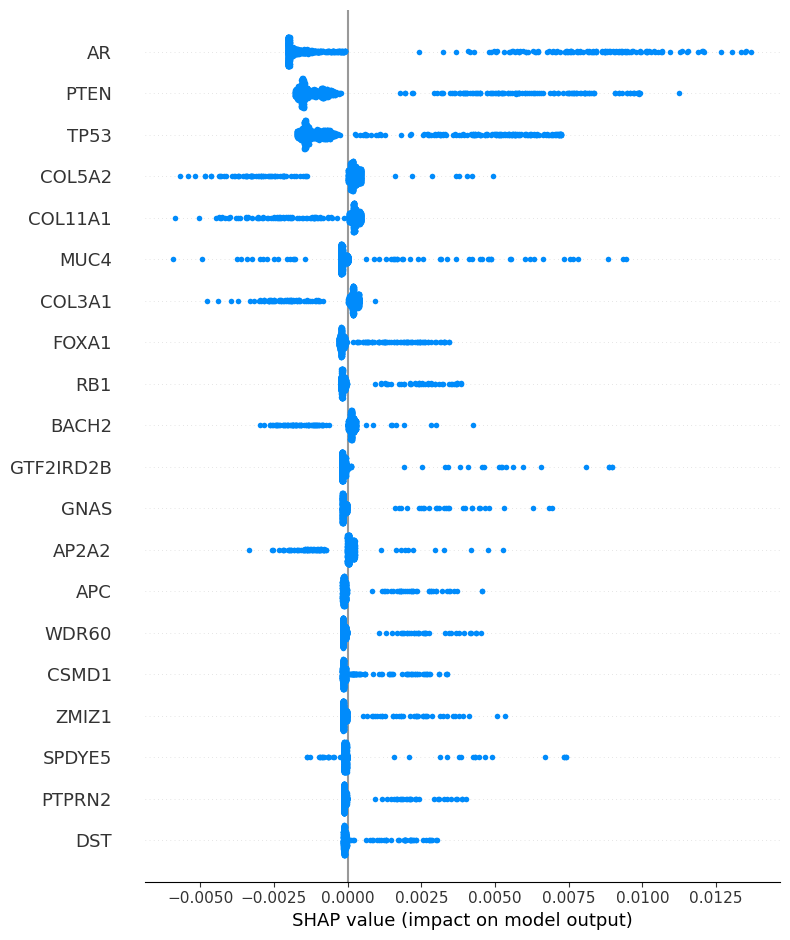

In [133]:
layer = 'Diagonal-Pancreas'
shap.summary_plot(train_shap[layer], feature_names=features[layer.split('-')[0]])

# TEMP SCRIPT